# Ultrasound Conus Detection — Training

Trains a lightweight **U-Net** (pretrained CNN backbone + skip-connection decoder)  
to segment the ultrasound conus region from ~300 manually annotated images.

**Annotations**: CVAT 1.1 XML format (polygons + boxes labelling the `us` region).

## Workflow
1. Mount Drive & set paths
2. Configure backbone, decoder, training hyperparams
3. **Train** with live loss / IoU / Dice plots
4. Resume from checkpoint (optional)
5. Evaluate and visualise predictions

In [ ]:
!ls /content

In [3]:
%matplotlib inline

import os, sys, csv, json, random
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.utils.data import DataLoader, Subset, random_split

# project root is two levels up from image_clenup/conus_detection/
PROJECT_ROOT = str(Path.cwd().resolve().parents[0])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Project root: /
PyTorch: 2.10.0+cu128
CUDA available: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuration

In [6]:
# ── Dataset ───────────────────────────────────────────────────────────────────
# Root directory containing annotations_1.xml, annotations_2.xml,
# for_annotation/ and for_annotation_2/ subdirectories.
DATASET_ROOT = "/content/drive/MyDrive/SHAD/project/conus_detection"

# ── Model ─────────────────────────────────────────────────────────────────────
# Any timm backbone that supports features_only=True.
# Lightweight options (good for ~300 images):
#   "efficientnet_b0"          ~5.3 M params, strong default
#   "mobilenetv3_small_100"    ~2.5 M params, fastest
#   "resnet18"                 ~11 M params, simple & reliable
BACKBONE         = "efficientnet_b0"
DECODER_CHANNELS = [256, 128, 64, 32]   # widths at 4 decoder up-stages
PRETRAINED       = True

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS       = 60
BATCH_SIZE   = 8
LR           = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SPLIT    = 0.2
NUM_WORKERS  = 4
TARGET_SIZE  = 512    # images resized to TARGET_SIZE × TARGET_SIZE
SEED         = 42

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_DIR = "/content/drive/MyDrive/SHAD/project/checkpoints/conus"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PATH_CHECKPOINT = os.path.join(OUTPUT_DIR, "best_conus.pt")
METRICS_CSV     = os.path.join(OUTPUT_DIR, "conus_metrics.csv")
CONFIG_PATH     = os.path.join(OUTPUT_DIR, "conus_run_config.json")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 2. Train

Live plots: **total loss**, **BCE / Dice components**, **IoU**, **Dice** (train / val).

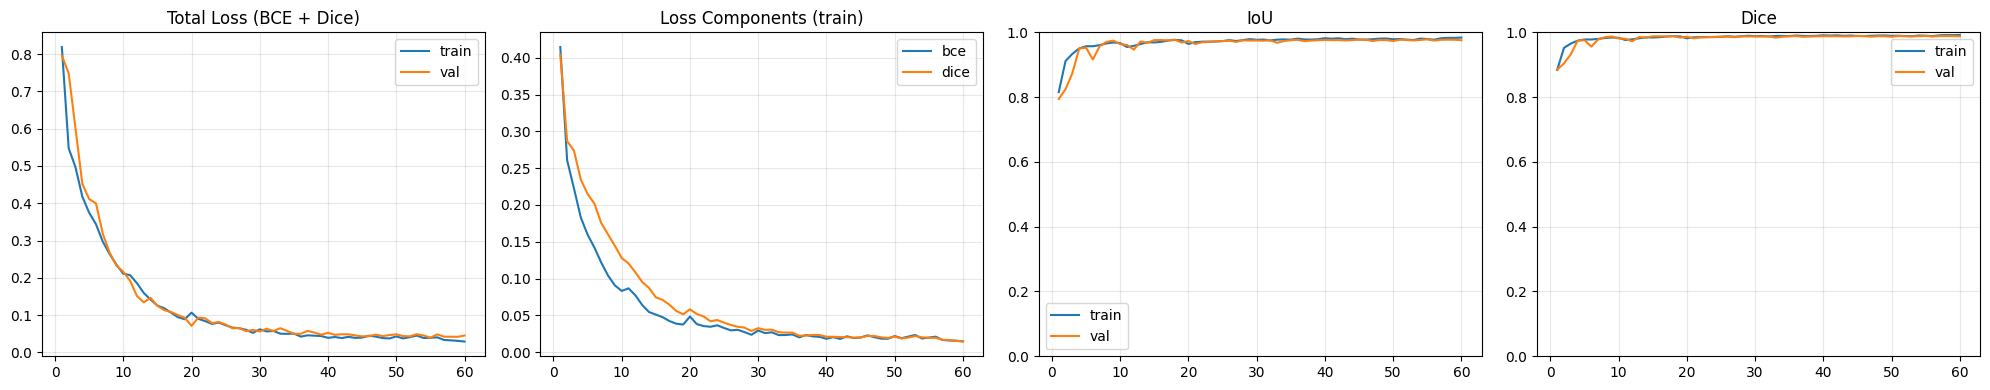

[ 60/60]  loss=0.0292/0.0455  |  iou=0.9838/0.9755  |  dice=0.9918/0.9876

Done. Best val IoU: 0.9785
Checkpoint: /content/drive/MyDrive/SHAD/project/checkpoints/conus/best_conus.pt


In [7]:
from image_clenup.conus_detection.dataset import ConusDataset
from image_clenup.conus_detection.model   import ConusUNet
from image_clenup.conus_detection.train   import (
    seg_loss, compute_metrics, train_one_epoch, evaluate,
    save_checkpoint,
)

torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)

# ── Dataset ───────────────────────────────────────────────────────────────────
train_full = ConusDataset(DATASET_ROOT, target_size=(TARGET_SIZE, TARGET_SIZE), augment=True)
val_full   = ConusDataset(DATASET_ROOT, target_size=(TARGET_SIZE, TARGET_SIZE), augment=False)

n_val   = max(1, int(len(train_full) * VAL_SPLIT))
n_train = len(train_full) - n_val
gen = torch.Generator().manual_seed(SEED)
train_idx, val_idx = random_split(range(len(train_full)), [n_train, n_val], generator=gen)
train_ds = Subset(train_full, list(train_idx))
val_ds   = Subset(val_full,   list(val_idx))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}")

# ── Model ─────────────────────────────────────────────────────────────────────
model = ConusUNet(
    backbone=BACKBONE,
    decoder_channels=DECODER_CHANNELS,
    pretrained=PRETRAINED,
).to(DEVICE)
print(f"Parameters: {model.n_params():,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── History ───────────────────────────────────────────────────────────────────
keys = ["train_loss", "train_bce", "train_dice", "train_iou", "train_dice_metric",
        "val_loss",   "val_bce",   "val_dice",   "val_iou",   "val_dice_metric"]
history = {k: [] for k in keys}

csv_file = open(METRICS_CSV, "w", newline="")
writer = csv.DictWriter(csv_file, fieldnames=["epoch"] + keys)
writer.writeheader()

config = {
    "dataset_root": DATASET_ROOT, "backbone": BACKBONE,
    "decoder_channels": DECODER_CHANNELS, "pretrained": PRETRAINED,
    "target_size": TARGET_SIZE, "epochs": EPOCHS, "batch_size": BATCH_SIZE,
    "lr": LR, "weight_decay": WEIGHT_DECAY, "val_split": VAL_SPLIT, "seed": SEED,
}

def update_plots(history, epochs_total):
    clear_output(wait=True)
    e = len(history["train_loss"])
    xs = range(1, e + 1)
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    axes[0].plot(xs, history["train_loss"], label="train", lw=1.5)
    axes[0].plot(xs, history["val_loss"],   label="val",   lw=1.5)
    axes[0].set_title("Total Loss (BCE + Dice)"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(xs, history["train_bce"],  label="bce",  lw=1.5)
    axes[1].plot(xs, history["train_dice"], label="dice", lw=1.5)
    axes[1].set_title("Loss Components (train)"); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(xs, history["train_iou"], label="train", lw=1.5)
    axes[2].plot(xs, history["val_iou"],   label="val",   lw=1.5)
    axes[2].set_title("IoU"); axes[2].legend(); axes[2].grid(alpha=0.3); axes[2].set_ylim(0, 1)

    axes[3].plot(xs, history["train_dice_metric"], label="train", lw=1.5)
    axes[3].plot(xs, history["val_dice_metric"],   label="val",   lw=1.5)
    axes[3].set_title("Dice"); axes[3].legend(); axes[3].grid(alpha=0.3); axes[3].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()
    print(
        f"[{e:3d}/{epochs_total}]  "
        f"loss={history['train_loss'][-1]:.4f}/{history['val_loss'][-1]:.4f}  |  "
        f"iou={history['train_iou'][-1]:.4f}/{history['val_iou'][-1]:.4f}  |  "
        f"dice={history['train_dice_metric'][-1]:.4f}/{history['val_dice_metric'][-1]:.4f}"
    )

# ── Training loop ─────────────────────────────────────────────────────────────
best_iou  = 0.0
hist_list = []

for epoch in range(1, EPOCHS + 1):
    tr = train_one_epoch(model, train_loader, optimizer, DEVICE)
    vl = evaluate(model, val_loader, DEVICE)

    history["train_loss"].append(tr["loss"])
    history["train_bce"].append(tr["bce"])
    history["train_dice"].append(tr["dice"])
    history["train_iou"].append(tr["iou"])
    history["train_dice_metric"].append(tr["dice_metric"])
    history["val_loss"].append(vl["loss"])
    history["val_bce"].append(vl["bce"])
    history["val_dice"].append(vl["dice"])
    history["val_iou"].append(vl["iou"])
    history["val_dice_metric"].append(vl["dice_metric"])

    row = {"epoch": epoch, **{k: f"{history[k][-1]:.6f}" for k in keys}}
    writer.writerow(row); csv_file.flush()
    hist_list.append(row)

    if vl["iou"] > best_iou:
        best_iou = vl["iou"]
        save_checkpoint(PATH_CHECKPOINT, model, optimizer, epoch, best_iou, config, hist_list)

    update_plots(history, EPOCHS)

csv_file.close()
config["history"] = hist_list
with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=2)

print(f"\nDone. Best val IoU: {best_iou:.4f}")
print(f"Checkpoint: {PATH_CHECKPOINT}")

## 3. Resume Training (optional)

In [ ]:
from image_clenup.conus_detection.train import load_checkpoint

start_epoch, best_iou, hist_list = load_checkpoint(PATH_CHECKPOINT, model, optimizer)
start_epoch += 1
for k in keys:
    history[k] = [float(r[k]) for r in hist_list if k in r]
print(f"Resumed from epoch {start_epoch - 1}, best IoU={best_iou:.4f}")

csv_file = open(METRICS_CSV, "a", newline="")
writer = csv.DictWriter(csv_file, fieldnames=["epoch"] + keys)

for epoch in range(start_epoch, EPOCHS + 1):
    tr = train_one_epoch(model, train_loader, optimizer, DEVICE)
    vl = evaluate(model, val_loader, DEVICE)

    history["train_loss"].append(tr["loss"])
    history["train_bce"].append(tr["bce"])
    history["train_dice"].append(tr["dice"])
    history["train_iou"].append(tr["iou"])
    history["train_dice_metric"].append(tr["dice_metric"])
    history["val_loss"].append(vl["loss"])
    history["val_bce"].append(vl["bce"])
    history["val_dice"].append(vl["dice"])
    history["val_iou"].append(vl["iou"])
    history["val_dice_metric"].append(vl["dice_metric"])

    row = {"epoch": epoch, **{k: f"{history[k][-1]:.6f}" for k in keys}}
    writer.writerow(row); csv_file.flush()
    hist_list.append(row)

    if vl["iou"] > best_iou:
        best_iou = vl["iou"]
        save_checkpoint(PATH_CHECKPOINT, model, optimizer, epoch, best_iou, config, hist_list)

    update_plots(history, EPOCHS)

csv_file.close()
print(f"\nDone. Best val IoU: {best_iou:.4f}")

## 4. Evaluate

In [8]:
from image_clenup.conus_detection.train import load_checkpoint, compute_metrics

load_checkpoint(PATH_CHECKPOINT, model, optimizer=None)
vl = evaluate(model, val_loader, DEVICE)

print(f"Val loss:  {vl['loss']:.4f}")
print(f"Val IoU:   {vl['iou']:.4f}")
print(f"Val Dice:  {vl['dice_metric']:.4f}")

Val loss:  0.0397
Val IoU:   0.9785
Val Dice:  0.9891


## 5. Visualise Predictions

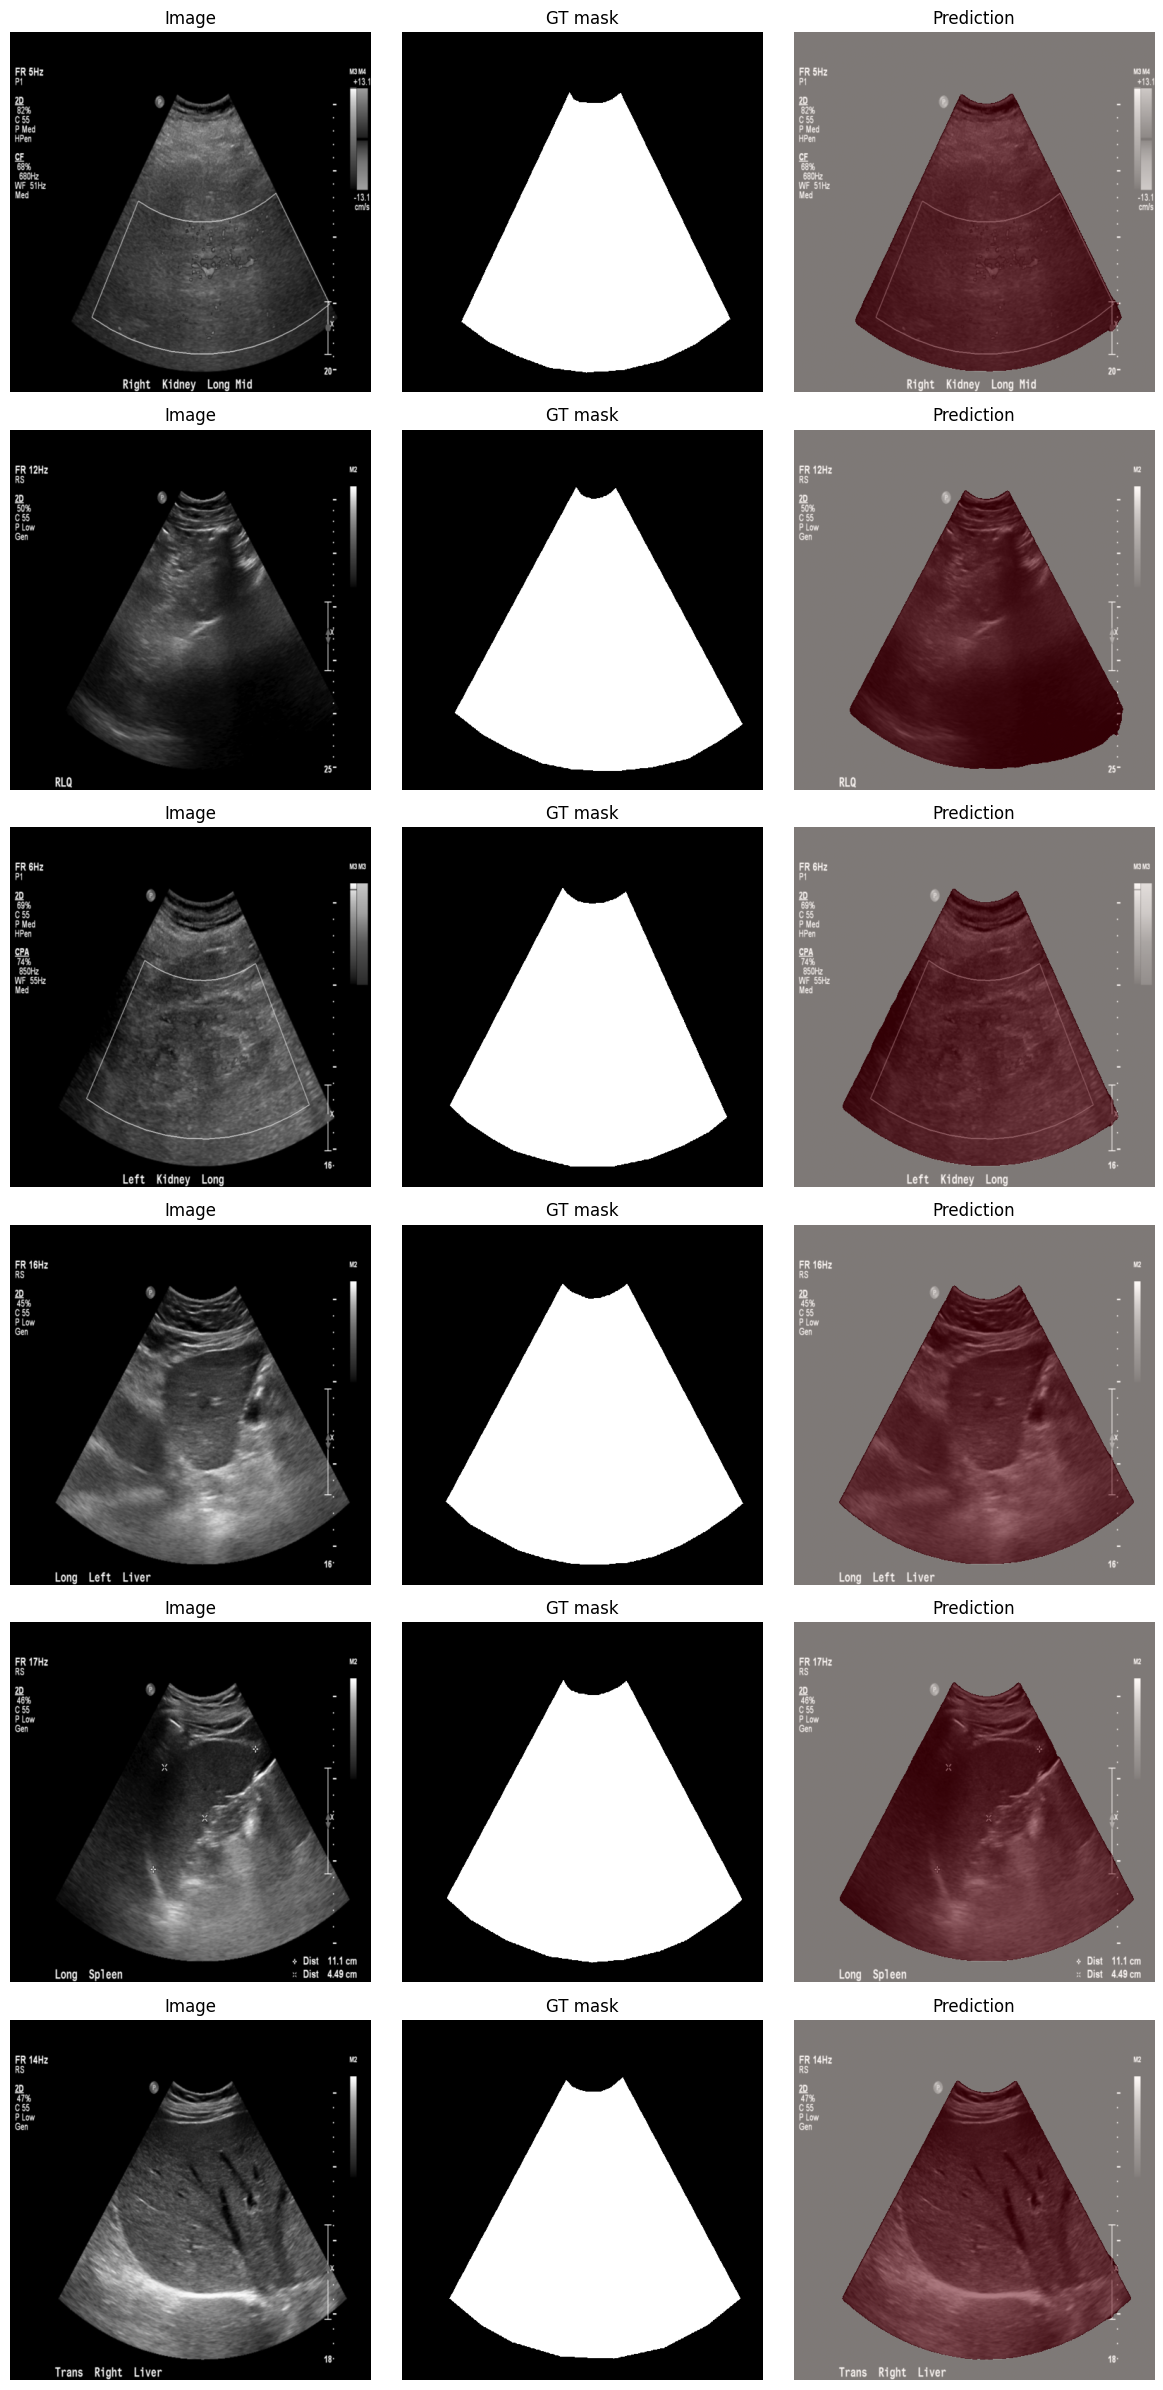

In [9]:
N_SHOW = 6

model.eval()
samples = [val_ds[i] for i in range(N_SHOW)]
imgs_t  = torch.stack([s["image"] for s in samples]).to(DEVICE)
masks_t = torch.stack([s["mask"]  for s in samples]).to(DEVICE)

with torch.no_grad():
    logits = model(imgs_t)
    preds  = (torch.sigmoid(logits) > 0.5).float()

imgs_np  = imgs_t.cpu().squeeze(1).numpy()   # [N, H, W]
masks_np = masks_t.cpu().squeeze(1).numpy()  # [N, H, W]
preds_np = preds.cpu().squeeze(1).numpy()    # [N, H, W]

fig, axes = plt.subplots(N_SHOW, 3, figsize=(12, 4 * N_SHOW))
for i in range(N_SHOW):
    axes[i, 0].imshow(imgs_np[i],  cmap="gray");        axes[i, 0].set_title("Image");      axes[i, 0].axis("off")
    axes[i, 1].imshow(masks_np[i], cmap="gray");        axes[i, 1].set_title("GT mask");     axes[i, 1].axis("off")
    axes[i, 2].imshow(imgs_np[i],  cmap="gray")
    axes[i, 2].imshow(preds_np[i], cmap="Reds", alpha=0.5, vmin=0, vmax=1)
    axes[i, 2].set_title("Prediction");                  axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## 6. Apply — crop image to conus region

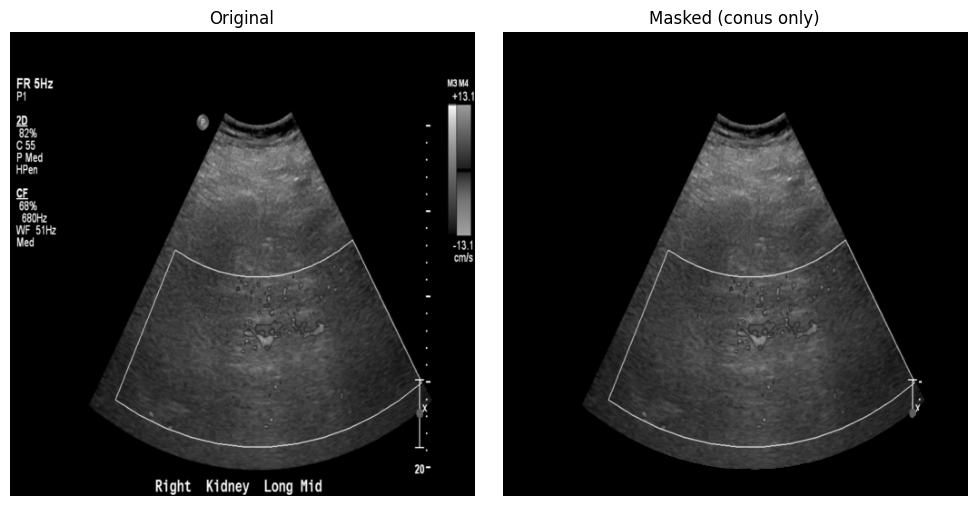

In [10]:
def apply_conus_mask(img_tensor: torch.Tensor, model: ConusUNet, device, threshold: float = 0.5):
    """Zero out everything outside the predicted conus. Returns masked image tensor."""
    model.eval()
    with torch.no_grad():
        mask = model.predict(img_tensor.unsqueeze(0).to(device), threshold=threshold).squeeze(0)
    return img_tensor * mask.cpu()

# Demo on first val sample
sample = val_ds[0]
img_orig   = sample["image"]                           # [1, H, W]
img_masked = apply_conus_mask(img_orig, model, DEVICE)  # [1, H, W]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_orig.squeeze().numpy(),   cmap="gray"); ax1.set_title("Original"); ax1.axis("off")
ax2.imshow(img_masked.squeeze().numpy(), cmap="gray"); ax2.set_title("Masked (conus only)"); ax2.axis("off")
plt.tight_layout()
plt.show()